## Assignment 2, Group 11

### Task 1:

In [1]:
# Importeringar
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

#### Loading csv data

In [2]:
# Importerar csv datan
df = pd.read_csv('segment_features.csv')

# Visar fem första rader i respektive kolumn
print(df.head(5))

   segment_id  user_id           file_name  mode  n_points  duration_s  \
0           0       10  20080331160008.plt   car        10       533.0   
1           1       10  20080331160008.plt   car        12       651.0   
2           2       10  20080402060926.plt  walk       563      1139.0   
3           3       10  20080402060926.plt   car       175       203.0   
4           4       10  20080402060926.plt   bus       266      1584.0   

    distance_m  avg_speed_mps  max_speed_mps  std_speed_mps  ...  \
0  4997.940935       8.432578      13.554139       4.878132  ...   
1  6031.302622       8.480828      19.759260       6.057875  ...   
2   755.418664       1.083157       3.848027       0.478953  ...   
3  1073.949583       5.936181      12.483375       3.656538  ...   
4  7326.510691       6.984778      16.513127       3.722160  ...   

   p90_speed_mps  avg_acc_mps2  std_acc_mps2  max_acc_mps2  min_acc_mps2  \
0      12.967964      0.015542      0.120639      0.209189     -0.2234

#### Importance plot

In [3]:
# Väljer features
features = df.drop(['segment_id', 'user_id', 'file_name', 'mode'], axis=1)
# Hämtar features namn
feature_names = features.columns

# Benämner X och y
X = df[feature_names]
y = df['mode']

# Splittar datan till träning och test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# Hämtar funktionen för random forest
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
# Tränar datan med random forest
rfc.fit(X_train, y_train)
# Hämtar feature importances från modellen
feature_importances = rfc.feature_importances_

# Skapar en dataframe av feature importances
importance_df = pd.DataFrame({
  'Features': feature_names,
  'Importance': feature_importances
})

# Sorterar dataframen i rangordning baserat på hur viktig den är
importance_df = importance_df.sort_values(by='Importance', ascending=True)

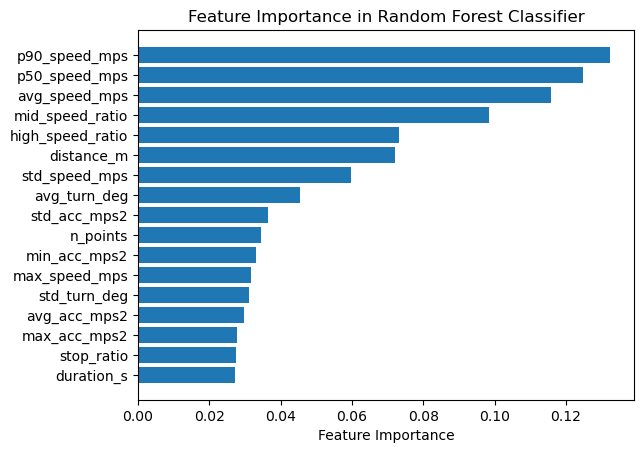

In [5]:
# Skapar en horizontell bar med namnen på features och dess importance
plt.barh(importance_df['Features'], importance_df['Importance'])
# Sätter titel, ettikett på x-axeln och visar diagrammet
plt.title('Feature Importance in Random Forest Classifier')
plt.xlabel('Feature Importance')
plt.show()


#### Bar chart of class distribution

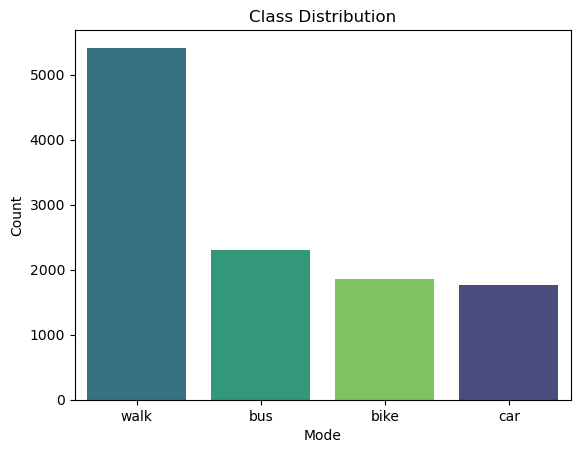

In [6]:
# Skapar en sns plot med countplot funktionen
sns.countplot(data=df, x='mode', hue='mode', palette='viridis', order=['walk', 'bus', 'bike', 'car'])
# Sätter titel, ettikett på x- och y-axeln samt visar diagrammet
plt.title('Class Distribution')
plt.xlabel('Mode')
plt.ylabel('Count')
plt.show()

### Task 2

#### Random forest

Accuracy: 84.47%
              precision    recall  f1-score   support

        bike       0.92      0.81      0.86       372
         bus       0.75      0.70      0.72       460
         car       0.80      0.74      0.77       351
        walk       0.87      0.95      0.91      1083

    accuracy                           0.84      2266
   macro avg       0.84      0.80      0.82      2266
weighted avg       0.84      0.84      0.84      2266



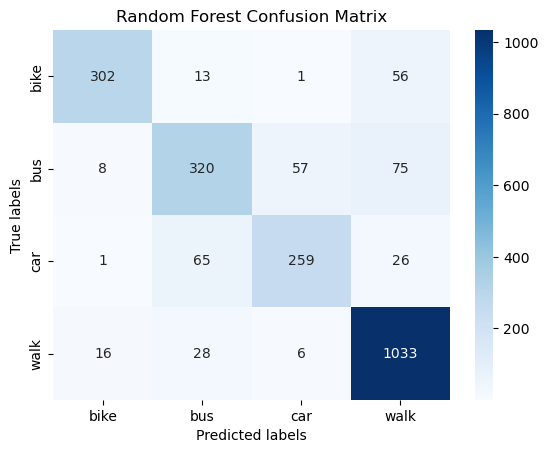

In [7]:
# Predikterar med random forest classifier
y_pred_forest = rfc.predict(X_test)

# Beräknar korrekthet
accuracy_forest = accuracy_score(y_test, y_pred_forest)

# Skapar en classification report 
report_forest = classification_report(y_test, y_pred_forest)

# Skriver ut korrekthet och classification report
print(f'Accuracy: {accuracy_forest * 100:.2f}%')
print(report_forest)

# Skapar sorterade ettiketter baserat på de unika transportsätt
labels = sorted(y.unique())
# Skapar en confusion matrix
confusion_forest = confusion_matrix(y_test, y_pred_forest)
# Skapar en heatmap baserat på confusion matrix:en
sns.heatmap(
  confusion_forest, 
  annot=True,
  fmt='g',
  cmap='Blues',
  xticklabels=labels,
  yticklabels=labels
)
# Sätter titel, ettikett på x- och y-axeln samt visar diagrammet
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()


#### KNN

KNN Accuracy: 81.07%
              precision    recall  f1-score   support

        bike       0.84      0.80      0.82       372
         bus       0.68      0.64      0.66       460
         car       0.74      0.64      0.69       351
        walk       0.87      0.94      0.90      1083

    accuracy                           0.81      2266
   macro avg       0.78      0.76      0.77      2266
weighted avg       0.81      0.81      0.81      2266



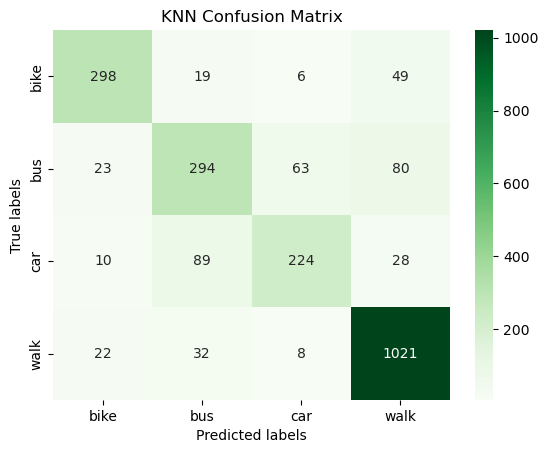

In [18]:
# Importerar funktionen för att standardisera datan
scaler = StandardScaler()
# Skalar features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Importerar funktionen för knn
knn = KNeighborsClassifier(n_neighbors=5)
# Tränar skalade features på knn
knn.fit(X_train_scaled, y_train)

# Predikterar transportsättet
y_pred_knn = knn.predict(X_test_scaled)

# Beräknar korrekthet
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Skapar en classification report
report_knn = classification_report(y_test, y_pred_knn)

# Skriver ut korrektheten och classification report
print(f'KNN Accuracy: {accuracy_knn * 100:.2f}%')
print(report_knn)

# Skapar en confusion matrix
confusion_knn = confusion_matrix(y_test, y_pred_knn)
# Skapar en heatmap baserat på confusion matrix:en
sns.heatmap(
    confusion_knn, 
    annot=True,
    fmt='g',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels
)
# Sätter titel, ettikett på x- och y-axeln samt visar diagrammet
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

#### SVM

SVM Accuracy: 81.51%
              precision    recall  f1-score   support

        bike       0.87      0.79      0.83       372
         bus       0.71      0.63      0.67       460
         car       0.76      0.63      0.69       351
        walk       0.85      0.96      0.90      1083

    accuracy                           0.82      2266
   macro avg       0.80      0.75      0.77      2266
weighted avg       0.81      0.82      0.81      2266



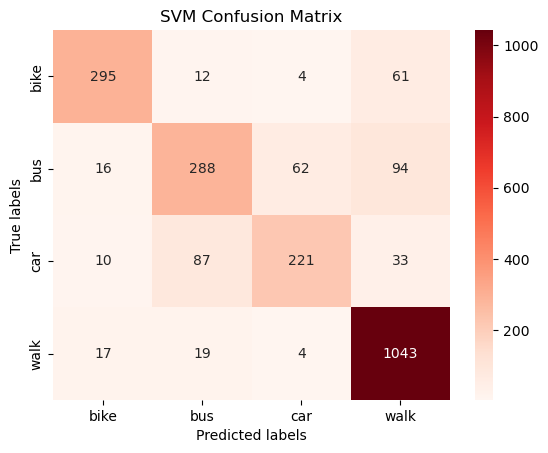

In [9]:
# Importerar funktionen för svm
svm = SVC(kernel='rbf', C=1, gamma='scale')

# Tränar skalade features på svm
svm.fit(X_train_scaled, y_train)

# Predikterar transportsättet
y_pred_svm = svm.predict(X_test_scaled)

# Beräknar korrekthet
accuracy_svm = accuracy_score(y_test, y_pred_svm)
# Skapar en classification report
report_svm = classification_report(y_test, y_pred_svm)

# Skriver ut korrektheten och classification report
print(f'SVM Accuracy: {accuracy_svm * 100:.2f}%')
print(report_svm)

# Skapar en confusion matrix
confusion_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)
# Skapar en heatmap baserat på confusion matrix:en
sns.heatmap(
    confusion_svm, 
    annot=True,
    fmt='g',
    cmap='Reds',
    xticklabels=labels,
    yticklabels=labels
)
# Sätter titel, ettikett på x- och y-axeln samt visar diagrammet
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()